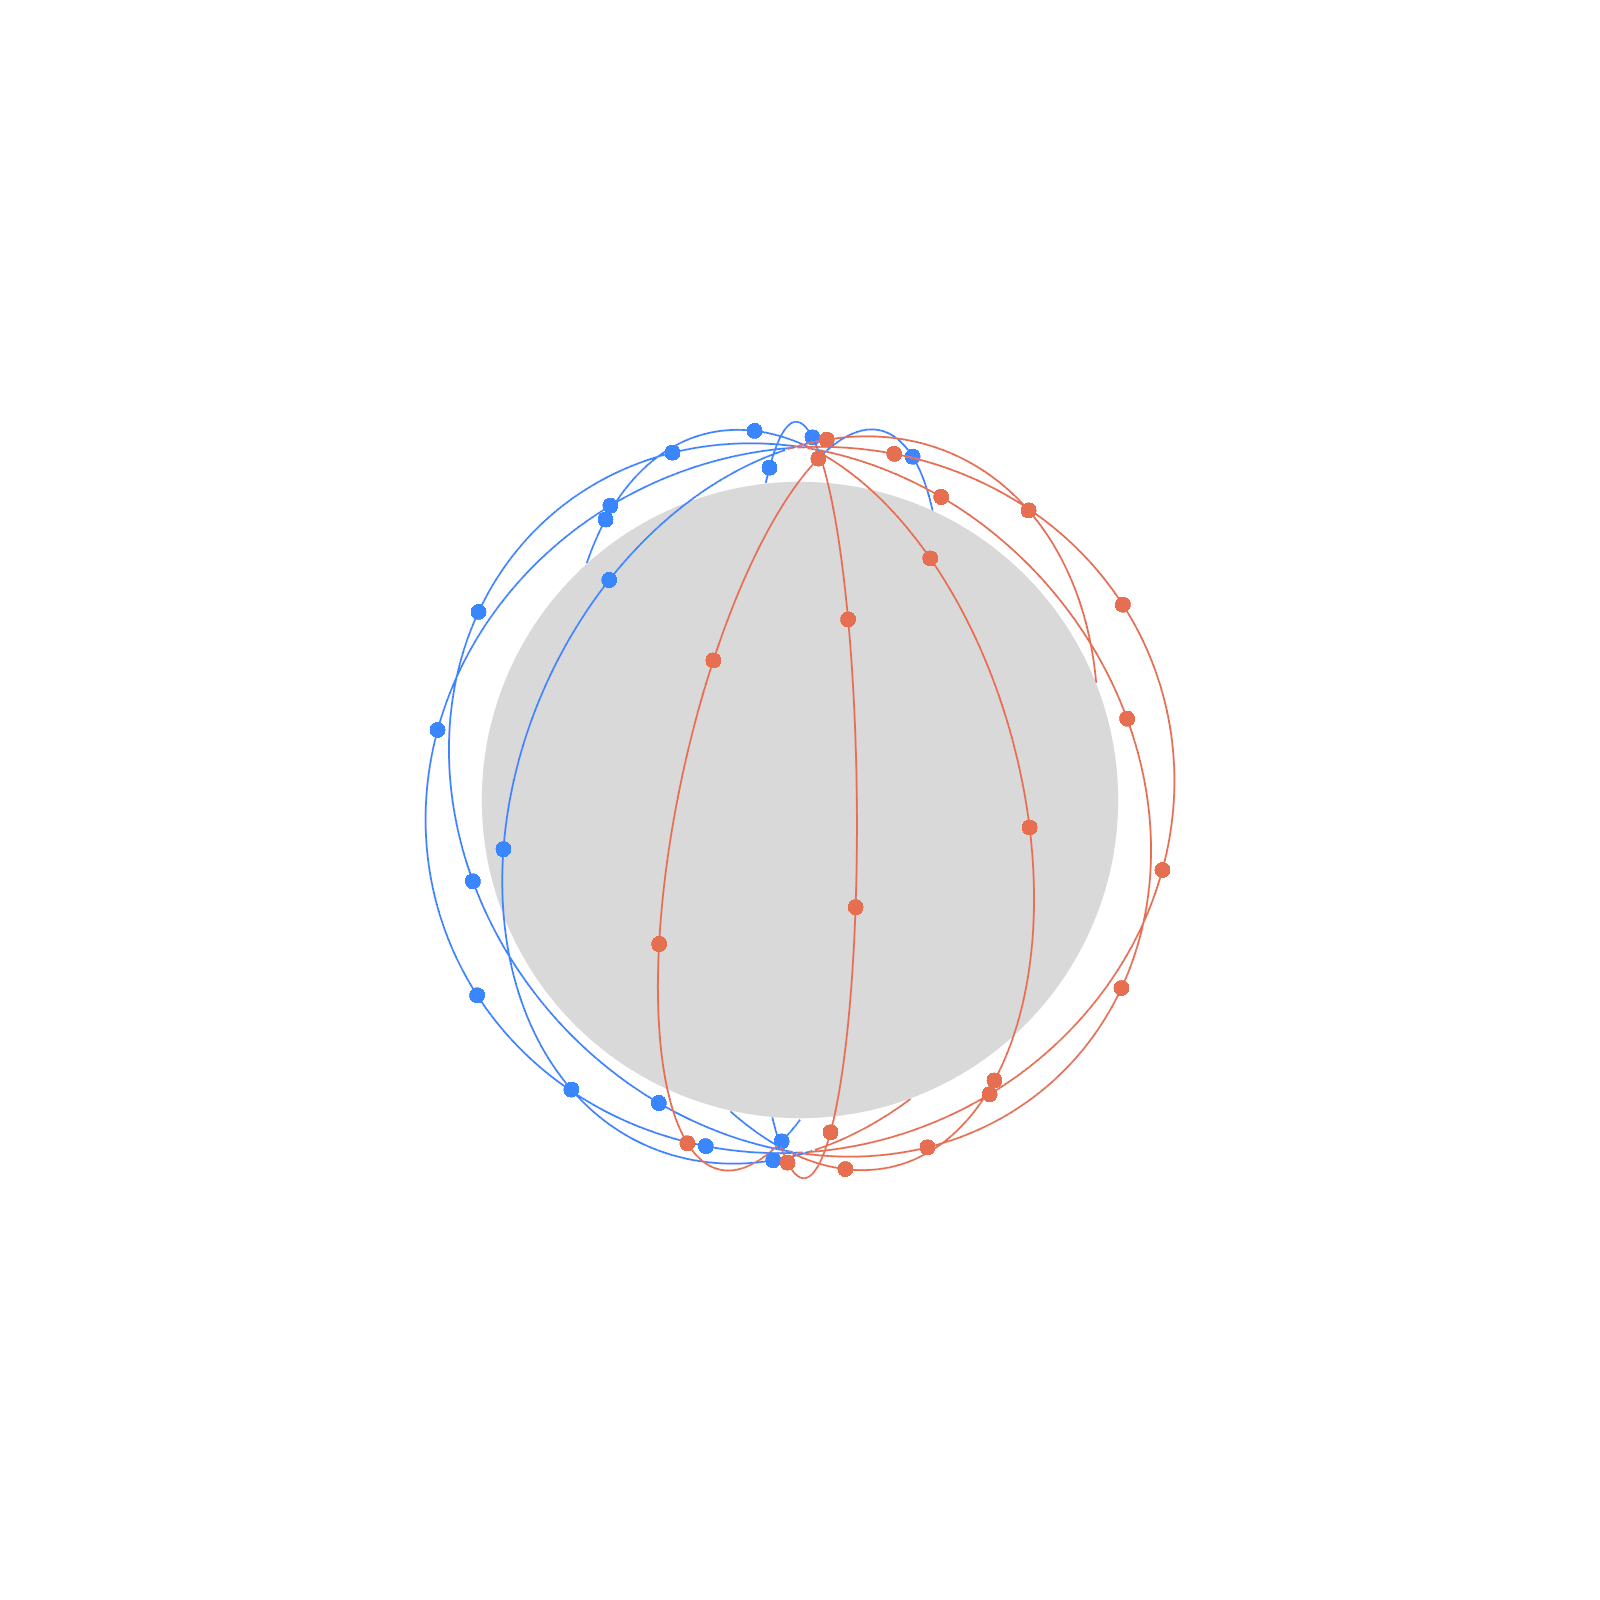

In [34]:

import pyvista as pv
import numpy as np
from PIL import Image

import IPython.display as display

R_earth = 6371.0

earth = pv.Sphere(
    radius=R_earth,
    center=(0, 0, 0),
    theta_resolution=180,
    phi_resolution=180
)

plotter = pv.Plotter(window_size=(1600, 1600), off_screen=True)

plotter.add_mesh(
    earth,
    color="#D9D9D9",   # 浅灰，最稳
    # color="lightblue",
    smooth_shading=False,   # 先关掉平滑高光
    lighting=False,         # 先关灯光，避免亮斑
    show_edges=False
)

plotter.set_background("white")
plotter.hide_axes()

# =========================
# 添加一条轨道
# =========================

# 轨道参数
# h = 1200.0                    # 轨道高度，单位 km
# r_orbit = R_earth + h         # 轨道半径
# inc_deg = 53.0                # 倾角
# raan_deg = 30.0               # 升交点赤经
# num_pts = 720                 # 采样点数，越大越平滑
#
# # 先在 x-y 平面生成一个圆轨道
# theta = np.linspace(0, 2*np.pi, num_pts, endpoint=False)
# x = r_orbit * np.cos(theta)
# y = r_orbit * np.sin(theta)
# z = np.zeros_like(theta)
#
# pts = np.column_stack((x, y, z))
#
# # 绕 x 轴旋转：施加倾角
# inc = np.deg2rad(inc_deg)
# Rx = np.array([
#     [1, 0, 0],
#     [0, np.cos(inc), -np.sin(inc)],
#     [0, np.sin(inc),  np.cos(inc)]
# ])
#
# # 绕 z 轴旋转：施加 RAAN
# raan = np.deg2rad(raan_deg)
# Rz = np.array([
#     [np.cos(raan), -np.sin(raan), 0],
#     [np.sin(raan),  np.cos(raan), 0],
#     [0, 0, 1]
# ])
#
# # 合成旋转
# pts = pts @ Rx.T
# pts = pts @ Rz.T
#
# # 生成闭合折线轨道
# orbit = pv.lines_from_points(pts, close=True)
#
# # 添加到场景
# plotter.add_mesh(
#     orbit,
#     color="tomato",
#     line_width=4
# )
#
# =========================
# 完成一条轨道
# =========================


# =========================================================
# Walker-Star-like constellation (schematic)
# 放在 plotter.hide_axes() 后面，camera_position 前面
# =========================================================

# -----------------------------
# A. 可调参数
# -----------------------------
inc_deg = 87.0              # 倾角 inclination
n_planes = 6                # 轨道面数
sats_per_plane = 8          # 每个轨道面卫星数（你可以改成 6/10/12 看效果）
alt_km = 1200.0             # 轨道高度
orbit_radius = R_earth + alt_km

first_raan_deg =15   # 第一个轨道面的 RAAN，单位度，可自由调整
raan_span_deg = 180.0
phase_f = 1
orbit_samples = 720




asc_color = "#E76F51"       # ascending segment 颜色
desc_color = "#3A86FF"      # descending segment 颜色

hidden_opacity = 0.18       # 被地球挡住时的透明度
visible_line_width = 2
hidden_line_width = 1


sat_point_size = 16         # 卫星点大小
show_hidden = True          # True: 画出被挡住部分(淡色)；False: 完全不画


# -----------------------------
# B. 旋转与轨道点生成函数
# -----------------------------
def rot_x(deg):
    a = np.deg2rad(deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(a), -np.sin(a)],
        [0, np.sin(a),  np.cos(a)]
    ])


def rot_z(deg):
    a = np.deg2rad(deg)
    return np.array([
        [ np.cos(a), -np.sin(a), 0],
        [ np.sin(a),  np.cos(a), 0],
        [0, 0, 1]
    ])


def orbit_xyz(radius, inc_deg, raan_deg, theta_rad):
    """
    在本征轨道平面先生成圆，然后施加 inclination 和 RAAN 旋转。
    """
    pts = np.column_stack((
        radius * np.cos(theta_rad),
        radius * np.sin(theta_rad),
        np.zeros_like(theta_rad)
    ))
    R = rot_z(raan_deg) @ rot_x(inc_deg)
    return pts @ R.T


def orbit_tangent_xyz(inc_deg, raan_deg, theta_rad):
    """
    返回轨道上各点的切向方向（未归一化也没关系）。
    用切向量的 z 分量判断：
    vz > 0 -> ascending
    vz < 0 -> descending
    """
    tang = np.column_stack((
        -np.sin(theta_rad),
         np.cos(theta_rad),
         np.zeros_like(theta_rad)
    ))
    R = rot_z(raan_deg) @ rot_x(inc_deg)
    return tang @ R.T

def make_orbit_points(radius, inc_deg, raan_deg, n=720):
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    return orbit_xyz(radius, inc_deg, raan_deg, theta)


# -----------------------------
# C. 基于“平行投影视角”的可见性判断
# -----------------------------
def visibility_mask_parallel(points, cam_pos, earth_radius):
    """
    对每个轨道点判断：
    1) 若投影落在地球圆盘外 -> 可见
    2) 若投影落在地球圆盘内，但点在地球前半空间 -> 可见
    3) 若投影落在地球圆盘内，且点在地球后半空间 -> 被遮挡
    """
    v = np.asarray(cam_pos, dtype=float)
    v = v / np.linalg.norm(v)   # 相机朝向单位向量（从地心指向相机）

    s = points @ v                           # 点沿视线方向的坐标
    perp = points - np.outer(s, v)          # 垂直于视线方向的分量
    rho = np.linalg.norm(perp, axis=1)      # 投影到像平面的半径

    hidden = (rho < earth_radius) & (s < 0)
    visible = ~hidden
    return visible, hidden


def split_closed_curve(points, mask):
    """
    把闭合曲线按 True/False 掩码切成若干连续段。
    返回若干段 points，每段至少 2 个点。
    """
    mask = np.asarray(mask, dtype=bool)
    n = len(mask)

    if mask.all():
        return [points.copy()]
    if (~mask).all():
        return []

    # 找一个 False -> True 的切入点，避免首尾连在一起时不好切
    transitions = np.where(mask != np.roll(mask, 1))[0]
    start = transitions[0]

    pts2 = np.roll(points, -start, axis=0)
    mask2 = np.roll(mask, -start)

    segments = []
    buf = []

    for p, m in zip(pts2, mask2):
        if m:
            buf.append(p)
        else:
            if len(buf) >= 2:
                segments.append(np.array(buf))
            buf = []

    if len(buf) >= 2:
        segments.append(np.array(buf))

    return segments


# -----------------------------
# D. 这里先定义“相机位置”，后面给 plotter 也用同一套
# -----------------------------
camera_pos = np.array([16000.0, 12000.0, 9000.0])


# -----------------------------
# E. 逐个轨道面生成
# -----------------------------
for k in range(n_planes):


    # 3 个轨道面沿 RAAN 均匀展开
    raan_deg = first_raan_deg + k * (raan_span_deg / n_planes)

     # 轨道参数采样角
    theta_orbit = np.linspace(0, 2*np.pi, orbit_samples, endpoint=False)

    # 轨道曲线
    orbit_pts = orbit_xyz(
        radius=orbit_radius,
        inc_deg=inc_deg,
        raan_deg=raan_deg,
        theta_rad=theta_orbit
    )

    # 轨道切向量，用于判断 ascending / descending
    orbit_tang = orbit_tangent_xyz(
        inc_deg=inc_deg,
        raan_deg=raan_deg,
        theta_rad=theta_orbit
    )

    asc_mask = orbit_tang[:, 2] >= 0
    desc_mask = ~asc_mask

    # 可见 / 被挡住
    vis_mask, hid_mask = visibility_mask_parallel(
        orbit_pts, camera_pos, R_earth
    )

    # -------------------------
    # 被地球挡住的 ascending 部分
    # -------------------------
    if show_hidden:
        for seg in split_closed_curve(orbit_pts, asc_mask & hid_mask):
            mesh = pv.lines_from_points(seg, close=False)
            plotter.add_mesh(
                mesh,
                color=asc_color,
                line_width=hidden_line_width,
                opacity=hidden_opacity
            )

        for seg in split_closed_curve(orbit_pts, desc_mask & hid_mask):
            mesh = pv.lines_from_points(seg, close=False)
            plotter.add_mesh(
                mesh,
                color=desc_color,
                line_width=hidden_line_width,
                opacity=hidden_opacity
            )

    # -------------------------
    # 可见的 ascending 部分
    # -------------------------
    for seg in split_closed_curve(orbit_pts, asc_mask & vis_mask):
        mesh = pv.lines_from_points(seg, close=False)
        plotter.add_mesh(
            mesh,
            color=asc_color,
            line_width=visible_line_width
        )

    # -------------------------
    # 可见的 descending 部分
    # -------------------------
    for seg in split_closed_curve(orbit_pts, desc_mask & vis_mask):
        mesh = pv.lines_from_points(seg, close=False)
        plotter.add_mesh(
            mesh,
            color=desc_color,
            line_width=visible_line_width
        )

    # -------------------------
    # 该轨道面上的卫星
    # 相邻轨道面做一点相位错开
    # -------------------------
    theta_sat = np.linspace(0, 2*np.pi, sats_per_plane, endpoint=False)

    # 相邻轨道面做一点相位偏移
    phase_offset_deg = k * (360.0 * phase_f / (n_planes * sats_per_plane))
    theta_sat = theta_sat + np.deg2rad(phase_offset_deg)

    sat_pts = orbit_xyz(
        radius=orbit_radius,
        inc_deg=inc_deg,
        raan_deg=raan_deg,
        theta_rad=theta_sat
    )

    # 用切向量判断卫星当前属于 ascending 还是 descending
    sat_tang = orbit_tangent_xyz(
        inc_deg=inc_deg,
        raan_deg=raan_deg,
        theta_rad=theta_sat
    )

    sat_asc = sat_tang[:, 2] >= 0
    sat_desc = ~sat_asc

    # 可见性
    sat_vis, sat_hid = visibility_mask_parallel(sat_pts, camera_pos, R_earth)

    # -------------------------
    # 被挡住的 ascending 卫星
    # -------------------------
    if show_hidden and np.any(sat_asc & sat_hid):
        plotter.add_points(
            sat_pts[sat_asc & sat_hid],
            color=asc_color,
            point_size=sat_point_size,
            opacity=0.30,
            render_points_as_spheres=True,
            lighting=False
        )

    # 被挡住的 descending 卫星
    if show_hidden and np.any(sat_desc & sat_hid):
        plotter.add_points(
            sat_pts[sat_desc & sat_hid],
            color=desc_color,
            point_size=sat_point_size,
            opacity=0.30,
            render_points_as_spheres=True,
            lighting=False
        )

    # -------------------------
    # 可见的 ascending 卫星
    # -------------------------
    if np.any(sat_asc & sat_vis):
        plotter.add_points(
            sat_pts[sat_asc & sat_vis],
            color=asc_color,
            point_size=sat_point_size,
            render_points_as_spheres=True,
            lighting=False
        )

    # 可见的 descending 卫星
    if np.any(sat_desc & sat_vis):
        plotter.add_points(
            sat_pts[sat_desc & sat_vis],
            color=desc_color,
            point_size=sat_point_size,
            render_points_as_spheres=True,
            lighting=False
        )

# 先给一个视角
# plotter.camera_position = [
#     (16000, 12000, 9000),
#     (0, 0, 0),
#     (0, 0, 1)
# ]

plotter.enable_parallel_projection()

plotter.camera_position = [
    tuple(camera_pos),
    (0, 0, 0),
    (0, 0, 1)
]

# 让整个星座都能完整装进画面
plotter.camera.parallel_scale = orbit_radius * 1.35

# 关键：重置相机，让整个场景进框
plotter.reset_camera()

# 再稍微缩远一点，避免顶到边框
plotter.camera.zoom(0.8)

img = plotter.screenshot(return_img=True)
plotter.close()

display.display(Image.fromarray(img))

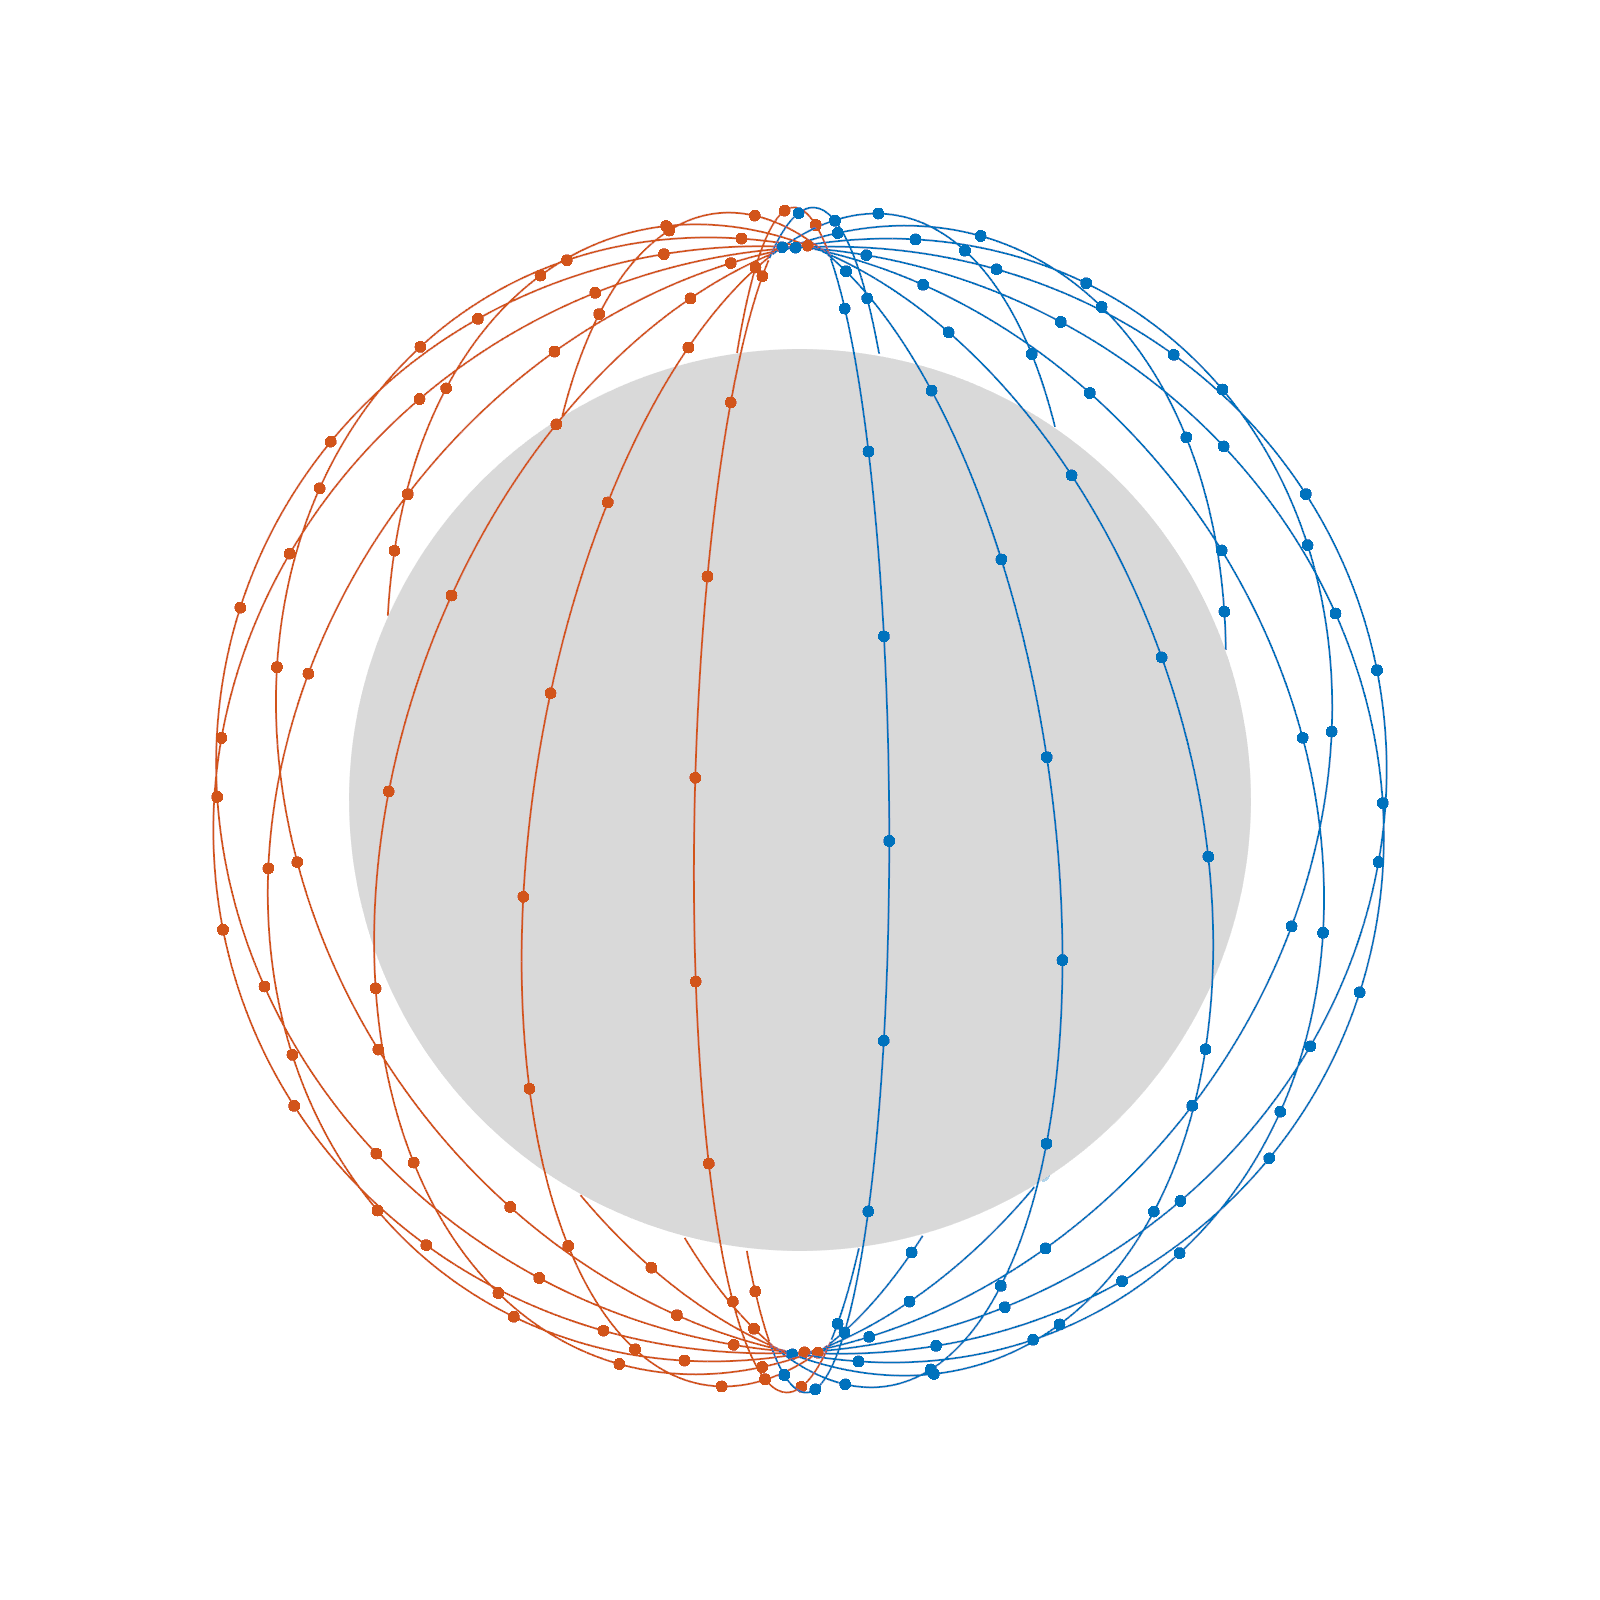

In [56]:
import pyvista as pv
import numpy as np
from PIL import Image
import IPython.display as display


# =========================================================
# 1. 基础参数
# =========================================================
R_earth = 6371.0  # km


# =========================================================
# 2. 基础旋转/轨道函数
# =========================================================
def rot_x(deg):
    a = np.deg2rad(deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(a), -np.sin(a)],
        [0, np.sin(a),  np.cos(a)]
    ])


def rot_z(deg):
    a = np.deg2rad(deg)
    return np.array([
        [ np.cos(a), -np.sin(a), 0],
        [ np.sin(a),  np.cos(a), 0],
        [0, 0, 1]
    ])


def orbit_xyz(radius, inc_deg, raan_deg, theta_rad):
    """
    在本征轨道平面先生成圆，然后施加 inclination 和 RAAN 旋转。
    """
    pts = np.column_stack((
        radius * np.cos(theta_rad),
        radius * np.sin(theta_rad),
        np.zeros_like(theta_rad)
    ))
    R = rot_z(raan_deg) @ rot_x(inc_deg)
    return pts @ R.T


def orbit_tangent_xyz(inc_deg, raan_deg, theta_rad):
    """
    返回轨道上各点的切向方向。
    用切向量 z 分量判断：
        vz > 0 -> ascending
        vz < 0 -> descending
    """
    tang = np.column_stack((
        -np.sin(theta_rad),
         np.cos(theta_rad),
         np.zeros_like(theta_rad)
    ))
    R = rot_z(raan_deg) @ rot_x(inc_deg)
    return tang @ R.T


# =========================================================
# 3. 可见性判断
# =========================================================
def visibility_mask_parallel(points, cam_pos, earth_radius):
    """
    基于平行投影视角判断点是否被地球遮挡。

    规则：
    1) 投影落在地球圆盘外 -> 可见
    2) 投影落在地球圆盘内，但点在地球前半空间 -> 可见
    3) 投影落在地球圆盘内，且点在地球后半空间 -> 被遮挡
    """
    v = np.asarray(cam_pos, dtype=float)
    v = v / np.linalg.norm(v)

    s = points @ v
    perp = points - np.outer(s, v)
    rho = np.linalg.norm(perp, axis=1)

    hidden = (rho < earth_radius) & (s < 0)
    visible = ~hidden
    return visible, hidden


def split_closed_curve(points, mask):
    """
    把闭合曲线按 True/False 掩码切成若干连续段。
    返回若干段 points，每段至少 2 个点。
    """
    mask = np.asarray(mask, dtype=bool)

    if mask.all():
        return [points.copy()]
    if (~mask).all():
        return []

    transitions = np.where(mask != np.roll(mask, 1))[0]
    start = transitions[0]

    pts2 = np.roll(points, -start, axis=0)
    mask2 = np.roll(mask, -start)

    segments = []
    buf = []

    for p, m in zip(pts2, mask2):
        if m:
            buf.append(p)
        else:
            if len(buf) >= 2:
                segments.append(np.array(buf))
            buf = []

    if len(buf) >= 2:
        segments.append(np.array(buf))

    return segments


# =========================================================
# 4. 绘制单个 Walker-Star-like 星座的函数
# =========================================================
def add_walker_star_constellation(
    plotter,
    *,
    R_earth,
    camera_pos,
    inc_deg=87.0,
    n_planes=6,
    sats_per_plane=8,
    alt_km=1200.0,
    first_raan_deg=15.0,
    raan_span_deg=180.0,
    phase_f=1,
    orbit_samples=720,
    asc_color="#E76F51",
    desc_color="#3A86FF",
    hidden_opacity=0.18,
    visible_line_width=2,
    hidden_line_width=1,
    sat_point_size=16,
    show_hidden=True,
    sat_hidden_opacity=0.30,
):
    """
    向当前 plotter 添加一个 Walker-Star-like 示意星座。
    返回该星座的轨道半径 orbit_radius，便于外部控制相机尺度。
    """
    orbit_radius = R_earth + alt_km

    for k in range(n_planes):
        # 各轨道面 RAAN
        raan_deg = first_raan_deg + k * (raan_span_deg / n_planes)

        # -------------------------
        # 轨道线
        # -------------------------
        theta_orbit = np.linspace(0, 2*np.pi, orbit_samples, endpoint=False)

        orbit_pts = orbit_xyz(
            radius=orbit_radius,
            inc_deg=inc_deg,
            raan_deg=raan_deg,
            theta_rad=theta_orbit
        )

        orbit_tang = orbit_tangent_xyz(
            inc_deg=inc_deg,
            raan_deg=raan_deg,
            theta_rad=theta_orbit
        )

        asc_mask = orbit_tang[:, 2] >= 0
        desc_mask = ~asc_mask

        vis_mask, hid_mask = visibility_mask_parallel(
            orbit_pts, camera_pos, R_earth
        )

        # 被地球挡住的 ascending / descending 轨道段
        if show_hidden:
            for seg in split_closed_curve(orbit_pts, asc_mask & hid_mask):
                mesh = pv.lines_from_points(seg, close=False)
                plotter.add_mesh(
                    mesh,
                    color=asc_color,
                    line_width=hidden_line_width,
                    opacity=hidden_opacity
                )

            for seg in split_closed_curve(orbit_pts, desc_mask & hid_mask):
                mesh = pv.lines_from_points(seg, close=False)
                plotter.add_mesh(
                    mesh,
                    color=desc_color,
                    line_width=hidden_line_width,
                    opacity=hidden_opacity
                )

        # 可见 ascending 轨道段
        for seg in split_closed_curve(orbit_pts, asc_mask & vis_mask):
            mesh = pv.lines_from_points(seg, close=False)
            plotter.add_mesh(
                mesh,
                color=asc_color,
                line_width=visible_line_width
            )

        # 可见 descending 轨道段
        for seg in split_closed_curve(orbit_pts, desc_mask & vis_mask):
            mesh = pv.lines_from_points(seg, close=False)
            plotter.add_mesh(
                mesh,
                color=desc_color,
                line_width=visible_line_width
            )

        # -------------------------
        # 卫星点
        # -------------------------
        theta_sat = np.linspace(0, 2*np.pi, sats_per_plane, endpoint=False)

        # 相邻轨道面相位偏移
        phase_offset_deg = k * (360.0 * phase_f / (n_planes * sats_per_plane))
        theta_sat = theta_sat + np.deg2rad(phase_offset_deg)

        sat_pts = orbit_xyz(
            radius=orbit_radius,
            inc_deg=inc_deg,
            raan_deg=raan_deg,
            theta_rad=theta_sat
        )

        sat_tang = orbit_tangent_xyz(
            inc_deg=inc_deg,
            raan_deg=raan_deg,
            theta_rad=theta_sat
        )

        sat_asc = sat_tang[:, 2] >= 0
        sat_desc = ~sat_asc

        sat_vis, sat_hid = visibility_mask_parallel(
            sat_pts, camera_pos, R_earth
        )

        # 被挡住的 ascending 卫星
        if show_hidden and np.any(sat_asc & sat_hid):
            plotter.add_points(
                sat_pts[sat_asc & sat_hid],
                color=asc_color,
                point_size=sat_point_size,
                opacity=sat_hidden_opacity,
                render_points_as_spheres=True,
                lighting=False
            )

        # 被挡住的 descending 卫星
        if show_hidden and np.any(sat_desc & sat_hid):
            plotter.add_points(
                sat_pts[sat_desc & sat_hid],
                color=desc_color,
                point_size=sat_point_size,
                opacity=sat_hidden_opacity,
                render_points_as_spheres=True,
                lighting=False
            )

        # 可见的 ascending 卫星
        if np.any(sat_asc & sat_vis):
            plotter.add_points(
                sat_pts[sat_asc & sat_vis],
                color=asc_color,
                point_size=sat_point_size,
                render_points_as_spheres=True,
                lighting=False
            )

        # 可见的 descending 卫星
        if np.any(sat_desc & sat_vis):
            plotter.add_points(
                sat_pts[sat_desc & sat_vis],
                color=desc_color,
                point_size=sat_point_size,
                render_points_as_spheres=True,
                lighting=False
            )

    return orbit_radius


# =========================================================
# 5. 创建地球和画布
# =========================================================
earth = pv.Sphere(
    radius=R_earth,
    center=(0, 0, 0),
    theta_resolution=180,
    phi_resolution=180
)

plotter = pv.Plotter(window_size=(1600, 1600), off_screen=True)

plotter.add_mesh(
    earth,

    color="#D9D9D9" ,  # 浅灰，最稳
    smooth_shading=False,
    lighting=False,
    show_edges=False
)

plotter.set_background("white")
plotter.hide_axes()


# =========================================================
# 6. 相机位置
# =========================================================
camera_pos = np.array([16000.0, 12000.0, 9000.0])


# =========================================================
# 7. 调用函数绘制星座
#    你后面要画多个星座，就继续多调用几次
# =========================================================

# 星座 1
orbit_radius_1 = add_walker_star_constellation(
    plotter,
    R_earth=R_earth,
    camera_pos=camera_pos,
    inc_deg=87.0,
    n_planes=10,
    sats_per_plane=18,
    alt_km=2000.0,
    first_raan_deg=45.0,
    raan_span_deg=180.0,
    phase_f=3,
    orbit_samples=720,
    asc_color= "#0072BD",
    desc_color="#D2541A",
    hidden_opacity=0.18,
    visible_line_width=2,
    hidden_line_width=1,
    sat_point_size=12,
    show_hidden=True,
)

# 如果你想再叠加第二个星座，直接取消下面注释即可

# orbit_radius_2 = add_walker_star_constellation(
#     plotter,
#     R_earth=R_earth,
#     camera_pos=camera_pos,
#     inc_deg=89.0,
#     n_planes=10,
#     sats_per_plane=16,
#     alt_km=3500.0,
#     first_raan_deg=40.0,
#     raan_span_deg=180.0,
#     phase_f=1,
#     orbit_samples=720,
#     asc_color="#2A9D8F",
#     desc_color="#8338EC",
#     hidden_opacity=0.12,
#     visible_line_width=2,
#     hidden_line_width=1,
#     sat_point_size=12,
#     show_hidden=True,
# )



# =========================================================
# 8. 相机设置
# =========================================================
max_orbit_radius = orbit_radius_1
# 如果你启用了第二个星座，就改成：
# max_orbit_radius = max(orbit_radius_1, orbit_radius_2)

plotter.enable_parallel_projection()

plotter.camera_position = [
    tuple(camera_pos),
    (0, 0, 0),
    (0, 0, 1)
]

plotter.camera.parallel_scale = max_orbit_radius * 1.35


# =========================================================
# 9. 输出图像
# =========================================================
# img = plotter.screenshot(return_img=True)
# plotter.close()
#
# display.display(Image.fromarray(img))

# =========================================================
# 9. 导出矢量图 + 预览图
# =========================================================

# 先导出矢量图
plotter.save_graphic(
    "walker_star.svg",
    raster=False,   # 尽量保留矢量
    painter=True
)

# 也顺手导出一个 PNG 预览，方便你快速检查
img = plotter.screenshot("walker_star_preview.png", return_img=True)

plotter.close()
display.display(Image.fromarray(img))


In [73]:
"""
Walker-Star 星座纯矢量 SVG 输出
=================================
每条轨道段、每颗卫星都是独立的 SVG <path> / <circle>，
带有语义化 id（如 s1-plane03-asc-vis），
可在 Illustrator / Inkscape 中逐一编辑。

用户参数单位是「屏幕像素」（和原 PyVista 参数一致），
脚本内部通过 px_scale 自动换算到 viewBox 的 km 坐标。
"""

import numpy as np
from xml.etree.ElementTree import Element, SubElement, tostring, indent

# =========================================================
# 1. 基础参数
# =========================================================
R_earth = 6371.0  # km

# =========================================================
# 2. 基础旋转 / 轨道函数
# =========================================================
def rot_x(deg):
    a = np.deg2rad(deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(a), -np.sin(a)],
        [0, np.sin(a),  np.cos(a)]
    ])

def rot_z(deg):
    a = np.deg2rad(deg)
    return np.array([
        [ np.cos(a), -np.sin(a), 0],
        [ np.sin(a),  np.cos(a), 0],
        [0, 0, 1]
    ])

def orbit_xyz(radius, inc_deg, raan_deg, theta_rad):
    pts = np.column_stack((
        radius * np.cos(theta_rad),
        radius * np.sin(theta_rad),
        np.zeros_like(theta_rad)
    ))
    R = rot_z(raan_deg) @ rot_x(inc_deg)
    return pts @ R.T

def orbit_tangent_xyz(inc_deg, raan_deg, theta_rad):
    tang = np.column_stack((
        -np.sin(theta_rad),
         np.cos(theta_rad),
         np.zeros_like(theta_rad)
    ))
    R = rot_z(raan_deg) @ rot_x(inc_deg)
    return tang @ R.T

# =========================================================
# 3. 正交投影 + 遮挡
# =========================================================
def build_camera_basis(cam_pos, up_hint=(0, 0, 1)):
    f = -np.asarray(cam_pos, dtype=float)
    f = f / np.linalg.norm(f)
    u = np.asarray(up_hint, dtype=float)
    r = np.cross(f, u);  r = r / np.linalg.norm(r)
    u = np.cross(r, f);  u = u / np.linalg.norm(u)
    return r, u, f

def project_ortho(points, right, up):
    x = points @ right
    y = -(points @ up)   # SVG y 轴朝下
    return np.column_stack((x, y))

def visibility_mask_parallel(points, cam_dir_unit, earth_radius):
    v = cam_dir_unit
    s = points @ v
    perp = points - np.outer(s, v)
    rho = np.linalg.norm(perp, axis=1)
    hidden = (rho < earth_radius) & (s < 0)
    return ~hidden, hidden

def split_closed_curve(points_2d, mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.all():
        return [points_2d.copy()]
    if (~mask).all():
        return []
    transitions = np.where(mask != np.roll(mask, 1))[0]
    start = transitions[0]
    pts2 = np.roll(points_2d, -start, axis=0)
    mask2 = np.roll(mask, -start)
    segments, buf = [], []
    for p, m in zip(pts2, mask2):
        if m:
            buf.append(p)
        else:
            if len(buf) >= 2:
                segments.append(np.array(buf))
            buf = []
    if len(buf) >= 2:
        segments.append(np.array(buf))
    return segments

# =========================================================
# 4. SVG 辅助
# =========================================================
def pts_to_svg_d(pts_2d):
    parts = [f"M{pts_2d[0,0]:.2f},{pts_2d[0,1]:.2f}"]
    for p in pts_2d[1:]:
        parts.append(f"L{p[0]:.2f},{p[1]:.2f}")
    return " ".join(parts)

# =========================================================
# 5. 星座绘制（写入 SVG group）
# =========================================================
def add_constellation_to_svg(
    parent_group,
    *,
    right, up, cam_dir,
    R_earth,
    px_scale,               # km / px 换算因子
    shell_label="shell1",
    inc_deg=87.0,
    n_planes=6,
    sats_per_plane=8,
    alt_km=1200.0,
    first_raan_deg=15.0,
    raan_span_deg=180.0,
    phase_f=1,
    orbit_samples=720,
    # ---- 样式参数单位：屏幕像素（和原 PyVista 一致） ----
    asc_color="#E76F51",
    desc_color="#3A86FF",
    visible_line_width=2.0,     # px
    hidden_line_width=1.0,      # px
    hidden_opacity=0.18,
    sat_point_size=12.0,        # px（直径，与 PyVista point_size 语义一致）
    sat_hidden_opacity=0.30,
    show_hidden=True,
):
    orbit_radius = R_earth + alt_km

    # 像素 → viewBox km 单位
    lw_vis = visible_line_width * px_scale
    lw_hid = hidden_line_width  * px_scale
    sat_r  = (sat_point_size / 2.0) * px_scale

    for k in range(n_planes):
        raan_deg = first_raan_deg + k * (raan_span_deg / n_planes)
        plane_id = f"{shell_label}-plane{k:02d}"

        # — 轨道线 —
        theta = np.linspace(0, 2*np.pi, orbit_samples, endpoint=False)
        pts3  = orbit_xyz(orbit_radius, inc_deg, raan_deg, theta)
        tang3 = orbit_tangent_xyz(inc_deg, raan_deg, theta)
        asc   = tang3[:, 2] >= 0
        desc  = ~asc
        vis, hid = visibility_mask_parallel(pts3, cam_dir, R_earth)
        pts2 = project_ortho(pts3, right, up)

        combos = [
            (asc & vis,  asc_color,  lw_vis, 1.0,            "asc-vis"),
            (desc & vis, desc_color, lw_vis, 1.0,            "desc-vis"),
            (asc & hid,  asc_color,  lw_hid, hidden_opacity, "asc-hid"),
            (desc & hid, desc_color, lw_hid, hidden_opacity, "desc-hid"),
        ]

        for mask, color, lw, opa, tag in combos:
            if tag.endswith("-hid") and not show_hidden:
                continue
            segs = split_closed_curve(pts2, mask)
            for si, seg in enumerate(segs):
                path = SubElement(parent_group, "path")
                path.set("id", f"{plane_id}-{tag}-{si}")
                path.set("d", pts_to_svg_d(seg))
                path.set("fill", "none")
                path.set("stroke", color)
                path.set("stroke-width", f"{lw:.2f}")
                path.set("stroke-linecap", "round")
                path.set("stroke-linejoin", "round")
                if opa < 1.0:
                    path.set("opacity", f"{opa:.2f}")

        # — 卫星点 —
        theta_sat = np.linspace(0, 2*np.pi, sats_per_plane, endpoint=False)
        phase_off = k * (360.0 * phase_f / (n_planes * sats_per_plane))
        theta_sat = theta_sat + np.deg2rad(phase_off)

        sat3     = orbit_xyz(orbit_radius, inc_deg, raan_deg, theta_sat)
        sat_tang = orbit_tangent_xyz(inc_deg, raan_deg, theta_sat)
        sat_asc  = sat_tang[:, 2] >= 0
        sat_desc = ~sat_asc
        sat_vis, sat_hid = visibility_mask_parallel(sat3, cam_dir, R_earth)
        sat2 = project_ortho(sat3, right, up)

        sat_combos = [
            (sat_asc & sat_vis,  asc_color,  1.0,                "asc-vis"),
            (sat_desc & sat_vis, desc_color, 1.0,                "desc-vis"),
            (sat_asc & sat_hid,  asc_color,  sat_hidden_opacity, "asc-hid"),
            (sat_desc & sat_hid, desc_color, sat_hidden_opacity, "desc-hid"),
        ]

        for mask, color, opa, tag in sat_combos:
            if tag.endswith("-hid") and not show_hidden:
                continue
            idxs = np.where(mask)[0]
            for j in idxs:
                circ = SubElement(parent_group, "circle")
                circ.set("id", f"{plane_id}-sat{j:02d}-{tag}")
                circ.set("cx", f"{sat2[j,0]:.2f}")
                circ.set("cy", f"{sat2[j,1]:.2f}")
                circ.set("r",  f"{sat_r:.2f}")
                circ.set("fill", color)
                if opa < 1.0:
                    circ.set("opacity", f"{opa:.2f}")

    return orbit_radius

# =========================================================
# 6. 主流程
# =========================================================
def main():
    W, H = 1600, 1600

    camera_pos = np.array([16000.0, 12000.0, 9000.0])
    right, up, fwd = build_camera_basis(camera_pos)
    cam_dir = camera_pos / np.linalg.norm(camera_pos)

    # ---- 预算 viewBox 和 px_scale ----
    alt_km_1 = 2500.0
    # alt_km_2 = 3500.0
    max_orbit_r = R_earth + alt_km_1
    # max_orbit_r = max(R_earth + alt_km_1, R_earth + alt_km_2)
    max_r    = max_orbit_r * 1.35
    px_scale = (2 * max_r) / W          # km per pixel

    print(f"  px_scale    = {px_scale:.4f} km/px")
    print(f"  2px 线宽    → {2*px_scale:.1f} km in viewBox")
    print(f"  12px 卫星   → r={6*px_scale:.1f} km in viewBox")

    # ---- SVG 根 ----
    svg = Element("svg")
    svg.set("xmlns", "http://www.w3.org/2000/svg")
    svg.set("width",  str(W))
    svg.set("height", str(H))
    svg.set("viewBox", f"{-max_r:.1f} {-max_r:.1f} {2*max_r:.1f} {2*max_r:.1f}")

    # ---- 白色背景（可选，方便预览） ----
    bg = SubElement(svg, "rect")
    bg.set("x", f"{-max_r:.1f}"); bg.set("y", f"{-max_r:.1f}")
    bg.set("width", f"{2*max_r:.1f}"); bg.set("height", f"{2*max_r:.1f}")
    bg.set("fill", "white")

    # ---- 地球 ----
    g_earth = SubElement(svg, "g")
    g_earth.set("id", "earth")
    circ = SubElement(g_earth, "circle")
    circ.set("cx", "0"); circ.set("cy", "0")
    circ.set("r", f"{R_earth:.2f}")
    circ.set("fill", "#D9D9D9")
    circ.set("stroke", "none")

    # ---- 星座 1 ----
    g1 = SubElement(svg, "g")
    g1.set("id", "constellation-1")

    orbit_r1 = add_constellation_to_svg(
        g1,
        right=right, up=up, cam_dir=cam_dir,
        R_earth=R_earth,
        px_scale=px_scale,
        shell_label="s1",
        inc_deg=90.0,
        n_planes=10,
        sats_per_plane=8,
        alt_km=alt_km_1,
        first_raan_deg=45.0,
        raan_span_deg=180.0,
        phase_f=3,
        orbit_samples=720,
        # ↓ 单位全是屏幕像素，和原 PyVista 参数完全一致
        asc_color="#0072BD",
        desc_color="#D2541A",
        visible_line_width=2.0,
        hidden_line_width=1.0,
        hidden_opacity=0.18,
        sat_point_size=12.0,
        sat_hidden_opacity=0.30,
        show_hidden=True,
    )

    # ---- 星座 2（取消注释即可启用） ----
    # g2 = SubElement(svg, "g")
    # g2.set("id", "constellation-2")
    #
    # orbit_r2 = add_constellation_to_svg(
    #     g2,
    #     right=right, up=up, cam_dir=cam_dir,
    #     R_earth=R_earth,
    #     px_scale=px_scale,
    #     shell_label="s2",
    #     inc_deg=89.0,
    #     n_planes=10,
    #     sats_per_plane=16,
    #     alt_km=alt_km_2,
    #     first_raan_deg=40.0,
    #     raan_span_deg=180.0,
    #     phase_f=1,
    #     orbit_samples=720,
    #     asc_color="#2A9D8F",
    #     desc_color="#8338EC",
    #     visible_line_width=2.0,
    #     hidden_line_width=1.0,
    #     hidden_opacity=0.12,
    #     sat_point_size=12.0,
    #     sat_hidden_opacity=0.30,
    #     show_hidden=True,
    # )

    # ---- 写文件 ----
    indent(svg, space="  ")
    raw = tostring(svg, encoding="unicode")
    content = '<?xml version="1.0" encoding="UTF-8"?>\n' + raw

    out_path = "walker_star_vector.svg"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(content)

    print(f"\n[OK] SVG 已保存: {out_path}")
    return out_path

if __name__ == "__main__":
    main()

  px_scale    = 14.9698 km/px
  2px 线宽    → 29.9 km in viewBox
  12px 卫星   → r=89.8 km in viewBox

[OK] SVG 已保存: walker_star_vector.svg


In [72]:
"""
Walker-Star 星座纯矢量 SVG 输出（无卫星点版）
===============================================
每条轨道段都是独立的 SVG <path>，
带有语义化 id（如 s1-plane03-asc-vis），
可在 Illustrator / Inkscape 中逐一编辑。
"""

import numpy as np
from xml.etree.ElementTree import Element, SubElement, tostring, indent

# =========================================================
# 1. 基础参数
# =========================================================
R_earth = 6371.0  # km

# =========================================================
# 2. 基础旋转 / 轨道函数
# =========================================================
def rot_x(deg):
    a = np.deg2rad(deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(a), -np.sin(a)],
        [0, np.sin(a),  np.cos(a)]
    ])

def rot_z(deg):
    a = np.deg2rad(deg)
    return np.array([
        [ np.cos(a), -np.sin(a), 0],
        [ np.sin(a),  np.cos(a), 0],
        [0, 0, 1]
    ])

def orbit_xyz(radius, inc_deg, raan_deg, theta_rad):
    pts = np.column_stack((
        radius * np.cos(theta_rad),
        radius * np.sin(theta_rad),
        np.zeros_like(theta_rad)
    ))
    R = rot_z(raan_deg) @ rot_x(inc_deg)
    return pts @ R.T

def orbit_tangent_xyz(inc_deg, raan_deg, theta_rad):
    tang = np.column_stack((
        -np.sin(theta_rad),
         np.cos(theta_rad),
         np.zeros_like(theta_rad)
    ))
    R = rot_z(raan_deg) @ rot_x(inc_deg)
    return tang @ R.T

# =========================================================
# 3. 正交投影 + 遮挡
# =========================================================
def build_camera_basis(cam_pos, up_hint=(0, 0, 1)):
    f = -np.asarray(cam_pos, dtype=float)
    f = f / np.linalg.norm(f)
    u = np.asarray(up_hint, dtype=float)
    r = np.cross(f, u);  r = r / np.linalg.norm(r)
    u = np.cross(r, f);  u = u / np.linalg.norm(u)
    return r, u, f

def project_ortho(points, right, up):
    x = points @ right
    y = -(points @ up)
    return np.column_stack((x, y))

def visibility_mask_parallel(points, cam_dir_unit, earth_radius):
    v = cam_dir_unit
    s = points @ v
    perp = points - np.outer(s, v)
    rho = np.linalg.norm(perp, axis=1)
    hidden = (rho < earth_radius) & (s < 0)
    return ~hidden, hidden

def split_closed_curve(points_2d, mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.all():
        return [points_2d.copy()]
    if (~mask).all():
        return []
    transitions = np.where(mask != np.roll(mask, 1))[0]
    start = transitions[0]
    pts2 = np.roll(points_2d, -start, axis=0)
    mask2 = np.roll(mask, -start)
    segments, buf = [], []
    for p, m in zip(pts2, mask2):
        if m:
            buf.append(p)
        else:
            if len(buf) >= 2:
                segments.append(np.array(buf))
            buf = []
    if len(buf) >= 2:
        segments.append(np.array(buf))
    return segments

# =========================================================
# 4. SVG 辅助
# =========================================================
def pts_to_svg_d(pts_2d):
    parts = [f"M{pts_2d[0,0]:.2f},{pts_2d[0,1]:.2f}"]
    for p in pts_2d[1:]:
        parts.append(f"L{p[0]:.2f},{p[1]:.2f}")
    return " ".join(parts)

# =========================================================
# 5. 星座绘制（仅轨道线，无卫星点）
# =========================================================
def add_constellation_to_svg(
    parent_group,
    *,
    right, up, cam_dir,
    R_earth,
    px_scale,
    shell_label="shell1",
    inc_deg=87.0,
    n_planes=6,
    alt_km=1200.0,
    first_raan_deg=15.0,
    raan_span_deg=180.0,
    orbit_samples=720,
    # ---- 样式（单位：屏幕像素） ----
    asc_color="#E76F51",
    desc_color="#3A86FF",
    visible_line_width=2.0,
    hidden_line_width=1.0,
    hidden_opacity=0.18,
    show_hidden=True,
):
    orbit_radius = R_earth + alt_km

    lw_vis = visible_line_width * px_scale
    lw_hid = hidden_line_width  * px_scale

    for k in range(n_planes):
        raan_deg = first_raan_deg + k * (raan_span_deg / n_planes)
        plane_id = f"{shell_label}-plane{k:02d}"

        theta = np.linspace(0, 2*np.pi, orbit_samples, endpoint=False)
        pts3  = orbit_xyz(orbit_radius, inc_deg, raan_deg, theta)
        tang3 = orbit_tangent_xyz(inc_deg, raan_deg, theta)
        asc   = tang3[:, 2] >= 0
        desc  = ~asc
        vis, hid = visibility_mask_parallel(pts3, cam_dir, R_earth)
        pts2 = project_ortho(pts3, right, up)

        combos = [
            (asc & vis,  asc_color,  lw_vis, 1.0,            "asc-vis"),
            (desc & vis, desc_color, lw_vis, 1.0,            "desc-vis"),
            (asc & hid,  asc_color,  lw_hid, hidden_opacity, "asc-hid"),
            (desc & hid, desc_color, lw_hid, hidden_opacity, "desc-hid"),
        ]

        for mask, color, lw, opa, tag in combos:
            if tag.endswith("-hid") and not show_hidden:
                continue
            segs = split_closed_curve(pts2, mask)
            for si, seg in enumerate(segs):
                path = SubElement(parent_group, "path")
                path.set("id", f"{plane_id}-{tag}-{si}")
                path.set("d", pts_to_svg_d(seg))
                path.set("fill", "none")
                path.set("stroke", color)
                path.set("stroke-width", f"{lw:.2f}")
                path.set("stroke-linecap", "round")
                path.set("stroke-linejoin", "round")
                if opa < 1.0:
                    path.set("opacity", f"{opa:.2f}")

    return orbit_radius

# =========================================================
# 6. 主流程
# =========================================================
def main():
    W, H = 1600, 1600

    camera_pos = np.array([16000.0, 12000.0, 9000.0])
    right, up, fwd = build_camera_basis(camera_pos)
    cam_dir = camera_pos / np.linalg.norm(camera_pos)

    alt_km_1 = 2000.0
    # alt_km_2 = 3500.0
    max_orbit_r = R_earth + alt_km_1
    # max_orbit_r = max(R_earth + alt_km_1, R_earth + alt_km_2)
    max_r    = max_orbit_r * 1.35
    px_scale = (2 * max_r) / W

    # ---- SVG 根 ----
    svg = Element("svg")
    svg.set("xmlns", "http://www.w3.org/2000/svg")
    svg.set("width",  str(W))
    svg.set("height", str(H))
    svg.set("viewBox", f"{-max_r:.1f} {-max_r:.1f} {2*max_r:.1f} {2*max_r:.1f}")

    bg = SubElement(svg, "rect")
    bg.set("x", f"{-max_r:.1f}"); bg.set("y", f"{-max_r:.1f}")
    bg.set("width", f"{2*max_r:.1f}"); bg.set("height", f"{2*max_r:.1f}")
    bg.set("fill", "white")

    # ---- 地球 ----
    g_earth = SubElement(svg, "g")
    g_earth.set("id", "earth")
    circ = SubElement(g_earth, "circle")
    circ.set("cx", "0"); circ.set("cy", "0")
    circ.set("r", f"{R_earth:.2f}")
    circ.set("fill", "#D9D9D9")
    circ.set("stroke", "none")

    # ---- 星座 1 ----
    g1 = SubElement(svg, "g")
    g1.set("id", "constellation-1")

    orbit_r1 = add_constellation_to_svg(
        g1,
        right=right, up=up, cam_dir=cam_dir,
        R_earth=R_earth,
        px_scale=px_scale,
        shell_label="s1",
        inc_deg=90.0,
        n_planes=10,
        alt_km=alt_km_1,
        first_raan_deg=45.0,
        raan_span_deg=180.0,
        orbit_samples=720,
        asc_color="#0072BD",
        desc_color="#D2541A",
        visible_line_width=2.0,
        hidden_line_width=1.0,
        hidden_opacity=0.18,
        show_hidden=True,
    )

    # ---- 星座 2（取消注释即可启用） ----
    # g2 = SubElement(svg, "g")
    # g2.set("id", "constellation-2")
    #
    # orbit_r2 = add_constellation_to_svg(
    #     g2,
    #     right=right, up=up, cam_dir=cam_dir,
    #     R_earth=R_earth,
    #     px_scale=px_scale,
    #     shell_label="s2",
    #     inc_deg=89.0,
    #     n_planes=10,
    #     alt_km=alt_km_2,
    #     first_raan_deg=40.0,
    #     raan_span_deg=180.0,
    #     orbit_samples=720,
    #     asc_color="#2A9D8F",
    #     desc_color="#8338EC",
    #     visible_line_width=2.0,
    #     hidden_line_width=1.0,
    #     hidden_opacity=0.12,
    #     show_hidden=True,
    # )

    # ---- 写文件 ----
    indent(svg, space="  ")
    raw = tostring(svg, encoding="unicode")
    content = '<?xml version="1.0" encoding="UTF-8"?>\n' + raw

    out_path = "walker_star_vector.svg"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(content)

    print(f"[OK] SVG 已保存: {out_path}")
    return out_path

if __name__ == "__main__":
    main()

[OK] SVG 已保存: walker_star_vector.svg
